***
This notebook is developed for neighborhood analysis demonstation using two kidney datasets.

Spatial Protein Imaging Workshop, May 21, 2026

John Hickey, Yang Miao

Duke University
***

# Import packages and functions

In [47]:
#Import Packages
import pandas as pd
import seaborn as sns
import numpy as np

import time
import sys
import matplotlib.pyplot as plt
import math
import os

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

Import some plotting functions

In [48]:
def catplot2(df,hue,exp = 'Exp',X = 'X',Y = 'Y',invert_y = False,size = 3,legend = True, 
             palette="bright",figsize = (8,6) ,style = 'white',exps = None,axis = 'on',scatter_kws = {}, 
             save_path=None):
    '''
    Plots cells in tissue section color coded by either cell type or node allocation.
    df:  dataframe with cell information
    size:  size of point to plot for each cell.
    hue:  color by "Clusterid" or "Node" respectively.
    legend:  to include legend in plot.
    '''
    scatter_kws_ = {'s':size,'alpha':1}
    scatter_kws_.update(scatter_kws)
    
    
    figures = []
    df = df.rename(columns = lambda x: str(x))
    
    df[hue] = df[hue].astype("category")
    if invert_y:
        y_orig = df[Y].values.copy()
        df[Y]*=-1


    style = {'axes.facecolor': style}
    sns.set_style(style)
    if exps == None:
        exps = list(df[exp].unique()) #display all experiments
    elif type(exps)!= list:
        exps = [exps]

    for name in exps:
        data = df[df[exp] == name]

        print (name)
        width, height = figsize
        aspect = width / height  # sns.lmplot wants aspect = width / height

        f = sns.lmplot(x = X,y = Y,data = data,hue = hue,
                   legend = legend,fit_reg = False,markers = '.', height=height, aspect=aspect, palette=palette,scatter = True,scatter_kws = scatter_kws_)

        # Make x and y have equal unit lengths
        plt.gca().set_aspect('equal', adjustable='box')

        if axis =='off':
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks = [],yticks=[]).set_xlabels('').set_ylabels('')   

        plt.title(name)

        # Save if requested
        if save_path:
            filename = f"{save_path}_{name}.png"
            f.fig.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Saved: {filename}")

        plt.show()
        figures +=[f] 
    if invert_y:
        df[Y] = y_orig
    
    return figures

In [49]:
def catplot2_specified(
    df, hue, include=None, exp='Exp', X='X', Y='Y',
    invert_y=False, size=3, legend=True, palette="bright",
    figsize=(8,6), style='white', exps=None, axis='on',
    scatter_kws=None, save_path=None, other_color="#F2F2F2"
):
    """
    Plot cells color-coded by `hue` (e.g., cell type).
    If `include` is provided (str or list), those categories are highlighted
    using `palette`; all other categories are shown in light gray.
    """
    scatter_kws_ = {'s': size, 'alpha': 1}
    if scatter_kws:
        scatter_kws_.update(scatter_kws)

    figures = []
    df = df.rename(columns=lambda x: str(x)).copy()

    # Optional Y inversion
    if invert_y:
        y_orig = df[Y].values.copy()
        df[Y] = -df[Y]

    sns.set_style(style)

    # Which experiments to plot
    if exps is None:
        exps = list(df[exp].unique())
    elif not isinstance(exps, list):
        exps = [exps]

    for name in exps:
        data = df[df[exp] == name].copy()

        # Determine highlighted vs other categories
        if include is not None:
            if not isinstance(include, (list, tuple, np.ndarray, pd.Index)):
                include_list = [include]
            else:
                include_list = list(include)
            others = [c for c in data[hue].dropna().unique() if c not in include_list]
            # Category order: highlighted first, then others
            data[hue] = pd.Categorical(data[hue], categories=include_list + others, ordered=False)

            # Build a palette dict: highlighted -> colors, others -> gray
            if isinstance(palette, dict):
                # Use provided mapping for highlighted; gray for others
                pal_map = {k: palette[k] for k in include_list if k in palette}
                for c in others:
                    pal_map[c] = other_color
            else:
                # Generate colors for highlighted; gray for others
                colors = sns.color_palette(palette, n_colors=len(include_list))
                pal_map = {k: col for k, col in zip(include_list, colors)}
                for c in others:
                    pal_map[c] = other_color
        else:
            # No include filter: just use provided palette
            data[hue] = data[hue].astype("category")
            if isinstance(palette, dict):
                pal_map = {k: v for k, v in palette.items() if k in data[hue].cat.categories}
            else:
                pal_map = palette

        print(name)
        width, height = figsize
        aspect = width / height

        f = sns.lmplot(
            x=X, y=Y, data=data, hue=hue, legend=legend, fit_reg=False,
            markers='.', height=height, aspect=aspect, palette=pal_map,
            scatter=True, scatter_kws=scatter_kws_
        )

        # Equal axis scaling
        plt.gca().set_aspect('equal', adjustable='box')

        if axis == 'off':
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks=[], yticks=[]).set_xlabels('').set_ylabels('')

        plt.title(name)

        if save_path:
            filename = f"{save_path}_{name}.png"
            f.fig.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Saved: {filename}")

        plt.show()
        figures.append(f)

    if invert_y:
        df[Y] = y_orig

    return figures

In [50]:
def stacked_bar_plot(
    data, per_cat, grouping, cell_list=None, norm=True, save_name=None,
    col_order=None, sub_col=None, name_cat='Cell Type', fig_sizing=(8,4),
    h_order=None, pal_color=None, remove_leg=False,
    include_noise=True, noise_label='Noise'   # <-- new
):
    # Work on a copy
    df = data.copy()

    # Ensure categorical for stable column order later
    df[per_cat] = df[per_cat].astype('category')

    # Optionally remove "Noise" (supports a single label or a collection)
    if not include_noise:
        if isinstance(noise_label, str):
            df = df[df[per_cat] != noise_label].copy()
            if hasattr(df[per_cat].dtype, "categories"):
                df[per_cat] = df[per_cat].cat.remove_categories([noise_label])
        elif isinstance(noise_label, Iterable):
            noise_label = list(noise_label)
            df = df[~df[per_cat].isin(noise_label)].copy()
            if hasattr(df[per_cat].dtype, "categories"):
                df[per_cat] = df[per_cat].cat.remove_categories(noise_label)

    # Count or percent by group × category
    if norm:
        tall = (
            df.groupby(grouping)[per_cat]
              .value_counts(normalize=True, sort=False)
              .mul(100).rename('percent').reset_index()
        )
    else:
        tall = (
            df.groupby(grouping)[per_cat]
              .value_counts(sort=False)
              .rename('percent').reset_index()
        )

    # Pivot to wide (rows = groups, cols = categories)
    piv = tall.pivot(index=grouping, columns=per_cat, values='percent').fillna(0)

    # Column (category) order
    if h_order is None:
        h_order = list(piv.columns)
    else:
        # If user passed an order containing Noise but it's excluded, drop it
        h_order = [c for c in h_order if c in piv.columns]

    # Group (x-axis) order
    if col_order is None:
        col_order = list(piv.sum(axis=1).sort_values().index)

    # Reindex to desired orders
    piv = piv.reindex(index=col_order, columns=h_order)

    # Colors
    if pal_color is None:
        cmap = plt.get_cmap('tab20')
        colors = [cmap(i % cmap.N) for i in range(len(piv.columns))]
        pal_color = dict(zip(piv.columns, colors))
    else:
        # If a dict was passed, keep only present categories
        if isinstance(pal_color, dict):
            pal_color = {k: v for k, v in pal_color.items() if k in piv.columns}

    # Plot
    ax1 = piv.plot.bar(
        alpha=0.8, linewidth=1, edgecolor='black',
        color=[pal_color[c] for c in piv.columns],
        figsize=fig_sizing, rot=90, stacked=True
    )
    for line in ax1.lines:
        line.set_color('black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    if remove_leg:
        ax1.set_ylabel('')
        ax1.set_xlabel('')
        ax1.legend_.remove()
    else:
        ax1.set_xlabel('Biopsy', fontsize=14)
        ax1.set_ylabel('Percentage (%)' if norm else 'count', fontsize=14)
        ax1.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, frameon=False, title=name_cat)

    plt.xticks(range(len(piv.index)), piv.index, rotation=90, fontsize=12)
    plt.yticks(fontsize=12)

    if save_name:
        plt.savefig(save_name + '.png', dpi=300, transparent=True, bbox_inches='tight')

    return piv, h_order


# Read in data

We can read in data from google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
data_path = r"/content/drive/MyDrive/20260519_spatialproteinimaging_workshop/CODEX_IU_OBrienWebinar_UpdatedAnnotations.xlsx"
df = pd.read_excel(data_path, sheet_name="Sheet1")
print(df.columns)

Map the cell cluster annotation back to each cell

In [54]:
map_df_1 = pd.read_excel(data_path, sheet_name="cluster_annotations")
mapping_1 = dict(zip(map_df_1["cluster number"], map_df_1["cluster"].str.strip()))
print(mapping_1)

map_df_2 = pd.read_excel(data_path, sheet_name="cluster_2_annotations")
mapping_2 = dict(zip(map_df_2["cluster number"], map_df_2["cluster_2"].str.strip()))
print(mapping_2)

{0: 'PT', 1: 'PT_S1_1', 2: 'TAL', 3: 'c-CT', 4: 'CD_PC', 5: 'EC', 6: 'STRM/VSM', 7: 'IMM', 8: 'Inj_PT', 9: 'PT_S1_2', 10: 'DCT', 11: 'Glom_EC', 12: 'STRM/VSMC/MC', 13: 'POD'}
{0: 'PT', 1: 'PT_S1_1', 2: 'TAL', 3: 'c-CT', 4: 'CD_PC', 5: 'EC', 6: 'STRM/VSM', 7: '_', 8: 'Inj_PT', 9: 'PT_S1_2', 10: 'DCT', 11: 'Glom_EC', 12: 'STRM/VSMC/MC', 13: 'POD', 14: 'DC_1', 15: 'Mac_1', 16: 'Mac_2', 17: 'NOS', 18: 'Mac/Myeloid', 19: 'T_CD4', 20: 'T_CD8', 21: 'DC_2', 22: 'DC_3'}


In [55]:
df['cell_type_level_1'] = df['cluster'].map(mapping_1)
df['cell_type_level_2'] = df['cluster_2'].map(mapping_2)
df

,X,Y,Biopsy,Object,cluster,cluster_2,cell_type_level_1,cell_type_level_2
0,810.5,10108.5,24-0165,0,2,2,TAL,TAL
1,822.5,10052.5,24-0165,1,11,11,Glom_EC,Glom_EC
2,820.5,10093.5,24-0165,2,2,2,TAL,TAL
3,822.5,10111.0,24-0165,3,2,2,TAL,TAL
4,824.5,10081.5,24-0165,4,2,2,TAL,TAL
...,...,...,...,...,...,...,...,...
73359,3442.0,20302.5,24-0168,41582,2,2,TAL,TAL
73360,3439.5,20389.0,24-0168,41583,4,4,CD_PC,CD_PC
73361,3441.5,19855.0,24-0168,41584,2,2,TAL,TAL
73362,3444.0,20000.5,24-0168,41585,0,0,PT,PT


We can briefly check the mapped cell type percentage for each single tissue

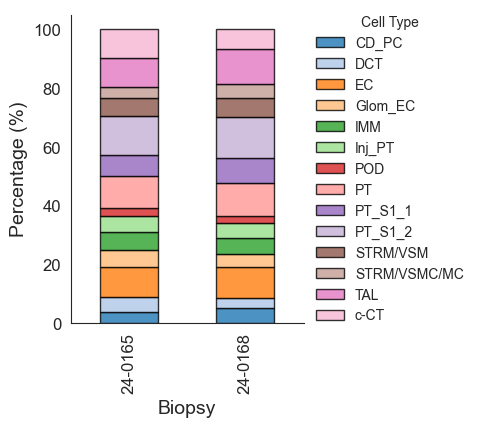

In [56]:
piv, h_order = stacked_bar_plot(
    data = df, 
    per_cat = 'cell_type_level_1', 
    grouping = 'Biopsy', 
    fig_sizing=(3,4), 
    name_cat ='Cell Type', 
)


# Import Additional Functions For Neighborhood Calculations
We need to add in additional functions that we will call to get the cellular neighborhoods.

There are many functions that we have written that we can call from these files without having to clutter our notebook.

This is one example of how such a function might look like and we will have access to them once we import the files.

Specifically this function is designed to identify and retrieve sets of nearest neighbors for each cell (or point) in a particular tissue sample, which is a crucial step in neighborhood analysis for CODEX data. By extracting subsets of cells based on shared spatial proximity, it effectively creates the “windows” of cells we need to study local interactions. Specifically, it selects a subset of data corresponding to a particular tissue regio (each has its own coordinate system), then uses scikit-learn’s NearestNeighbors algorithm to find a specified number of neighbors for each cell. The output is a structured list of neighbor indices for each cell, enabling us to cluster to identify cellular neighborhoods.

In [57]:
#Function for getting neighborhood windows

def get_windows(job, n_neighbors):

    # Unpack the job tuple containing start_time, idx, tissue_name, and indices
    start_time, idx, tissue_name, indices = job

    # Record the current time to measure the duration of the job
    job_start = time.time()

    # Print a message indicating the start of the job
    print("Starting:", str(idx+1)+'/'+str(len(exps)), ': ' + exps[idx])

    # Get the subset of the dataset for the specific tissue
    tissue = tissue_group.get_group(tissue_name)

    # Extract the coordinates (X, Y) for the points to be fitted from the tissue subset
    to_fit = tissue.loc[indices][[X, Y]].values

    # Fit the NearestNeighbors model on the tissue's X, Y coordinates
    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X, Y]].values)

    # Find the nearest neighbors for the points in 'to_fit'
    m = fit.kneighbors(to_fit)

    # Sort the neighbors
    # 'args' are the indices that would sort the distances
    args = m[0].argsort(axis=1)

    # 'add' is used to adjust indices for flattened array
    add = np.arange(m[1].shape[0]) * m[1].shape[1]

    # Calculate sorted indices for neighbors
    sorted_indices = m[1].flatten()[args + add[:, None]]

    # Retrieve the neighbor indices from the tissue dataset
    neighbors = tissue.index.values[sorted_indices]

    # Record the end time of the job
    end_time = time.time()

    # Print a message indicating the end of the job and the duration
    print("Finishing:", str(idx+1)+"/"+str(len(exps)), ": "+ exps[idx], end_time - job_start, end_time - start_time)

    # Return the neighbor indices as an array of integers
    return neighbors.astype(np.int32)


# Neighborhood analysis

## Set Columns to Use from Data
The only columns of the data we will need for neighborhood analysis are the x, y coordinates of the centroids of the cell, the unique region column that is connected with each set of unique regions, and the cell type column that contains all the annotations for each cell type.

In [58]:
df.columns

Index(['X', 'Y', 'Biopsy', 'Object', 'cluster', 'cluster_2',
       'cell_type_level_1', 'cell_type_level_2'],
      dtype='str')

It is important that the unique region truly is a unique region and there is no overlap. In this case there is a duplicate of a region with the same name. We need to drop or rename this extra data in order to do accurate cell neighborhood analysis

In this case, we use column 'Biopsy'

In [59]:
# Define column names that will be used for neighborhood analysis
X = 'X'                  # Variable for the X coordinate
Y = 'Y'                  # Variable for the Y coordinate
reg = 'Biopsy'         # Variable for the filename or region identifier associated with coordinates
cluster_col = 'cell_type_level_1'  # Variable for cell type/subtype classification

# List of columns to keep for analysis
keep_cols = [X, Y, reg, cluster_col]

Since the algorithm uses the index to algin computations when splitting up the data it is a good practice to reset index and save or reset index and drop

In [60]:
#Ensure unique values per region
df.reset_index(inplace=True, drop=True)

## Prepare the Data for Computation
Here we are creating dummy columns to store the counts of all the neighboring cell types for each individual cell and storing unique cell names.

In [61]:
# Concatenate the original 'cells' DataFrame with dummy variables created from 'cluster_col'
# pd.get_dummies() converts categorical variable(s) into dummy/indicator variables
cells = pd.concat([df, pd.get_dummies(df[cluster_col], dtype=int)], axis=1)
cells

,X,Y,Biopsy,Object,cluster,cluster_2,cell_type_level_1,cell_type_level_2,CD_PC,DCT,...,IMM,Inj_PT,POD,PT,PT_S1_1,PT_S1_2,STRM/VSM,STRM/VSMC/MC,TAL,c-CT
0,810.5,10108.5,24-0165,0,2,2,TAL,TAL,0,0,...,0,0,0,0,0,0,0,0,1,0
1,822.5,10052.5,24-0165,1,11,11,Glom_EC,Glom_EC,0,0,...,0,0,0,0,0,0,0,0,0,0
2,820.5,10093.5,24-0165,2,2,2,TAL,TAL,0,0,...,0,0,0,0,0,0,0,0,1,0
3,822.5,10111.0,24-0165,3,2,2,TAL,TAL,0,0,...,0,0,0,0,0,0,0,0,1,0
4,824.5,10081.5,24-0165,4,2,2,TAL,TAL,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73359,3442.0,20302.5,24-0168,41582,2,2,TAL,TAL,0,0,...,0,0,0,0,0,0,0,0,1,0
73360,3439.5,20389.0,24-0168,41583,4,4,CD_PC,CD_PC,1,0,...,0,0,0,0,0,0,0,0,0,0
73361,3441.5,19855.0,24-0168,41584,2,2,TAL,TAL,0,0,...,0,0,0,0,0,0,0,0,1,0
73362,3444.0,20000.5,24-0168,41585,0,0,PT,PT,0,0,...,0,0,0,1,0,0,0,0,0,0


Now we store all the unique cell types in the order we have them within our dataframe to maintain the index

In [62]:
# Get unique values from the 'cluster_col' column to use for summarization
sum_cols = cells[cluster_col].unique()
sum_cols

<ArrowStringArray>
[         'TAL',      'Glom_EC',     'STRM/VSM',      'PT_S1_2',
           'EC',         'c-CT',          'POD',          'DCT',
 'STRM/VSMC/MC',           'PT',        'CD_PC',      'PT_S1_1',
       'Inj_PT',          'IMM']
Length: 14, dtype: str

Let's view the specific dataframe we just created and separate it for calculation sake

In [63]:
# Retrieve the values for these unique categories as a NumPy array
# This array can be used for further analysis or operations later for calculating the neighborhoods
values = cells[sum_cols].values
values

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(73364, 14))

## Find neighbors for each cell
The first part of the code is to find and construct a graph around each cell based on the max number of nearest neighbor values you set.

First we set the number of nearest neighbors that we want to calculate within each window. We can also loop the calculation to do it over a list of values like is within this example

In [64]:
#We can choose a range of nearest neighbors to calculate the neighborhoods
ks = [10] # k=10 means it collects 10 nearest neighbors for each center cell

While it is good to explore multiple nearest neighbor values for your biology and biological question, we will only explore one here.

In [65]:
n_neighbors = max(ks) # sets n_neighbors to max of the list that is set

Now to calculate the neighborhoods we have to get things ready for the function. First we groupby each region since we will need to compute on a per region basis.

In [66]:
# Group the cell data by region
# 'tissue_group' will be a GroupBy object with cells grouped by the 'reg' column (representing regions)
tissue_group = cells[[X, Y, reg]].groupby(reg)

Next we get a list of unique regions. In our case they are the filenames

In [67]:
# 'exps' will contain all unique region names found in the 'reg' column of the 'cells' DataFrame
exps = list(cells[reg].unique())

Next we "chunk" the tissues into separate iterable objects.

In [68]:
# Prepare chunks of data for processing
# 'tissue_chunks' is a list of tuples, each tuple representing a job for processing
# Each tuple contains the current time, index of the region in 'exps', the region name, and a subset of indices
# 'np.array_split(indices, 1)' splits the indices for each group into chunks (1 chunk in this case)
# This loop goes through each group in 'tissue_group', and for each group, it creates a job tuple
tissue_chunks = [(time.time(), exps.index(t), t, a) for t, indices in tissue_group.groups.items() for a in np.array_split(indices, 1)]

Now we pass this tissue_chunks into our function we previously defined `get_windows` to calculate the neighborhoods separately for each individual tissue

In [69]:
# Process each job to get the windows (neighbors of the cells)
# 'tissues' is a list of results from the 'get_windows' function
# The 'get_windows' function is applied to each job in 'tissue_chunks'
# 'n_neighbors' is a parameter for the 'get_windows' function, defining the number of neighbors to consider
tissues = [get_windows(job, n_neighbors) for job in tissue_chunks]

Starting: 1/2 : 24-0165
Finishing: 1/2 : 24-0165 0.05499410629272461 0.05918097496032715
Starting: 2/2 : 24-0168
Finishing: 2/2 : 24-0168 0.06726598739624023 0.12672781944274902


## Formatting the windows
This next part of the code takes these calculated neighbor graphs that you calculated to find the number of neighbors of each cell for each value of k (number of neighbors) previously set above

`tissues` now represents an array of indices of the nearest neighbor for each individual region.

In [70]:
print(len(tissues)) #a list of the number of tissues

2


In [71]:
tissues[0].shape # number of cells by count of cells k

(31777, 10)

In [72]:
tissues[0] # We can see the indice of each cell is returned as an array with its nearest neighbor indices

array([[    0,     3,     2, ...,     1,     8,  1159],
       [    1,     4,     7, ...,  1098,     0,     3],
       [    2,     4,     3, ...,  1098,  1159,  1116],
       ...,
       [31774,    18, 31766, ..., 31770, 31767,   103],
       [31775,    70,   189, ..., 31743,   282, 31754],
       [31776,    94, 31772, ..., 12307, 31758,   213]],
      shape=(31777, 10), dtype=int32)

However, we want the counts of each individual cell type to be able to cluster them. So this next step we loop through each k value and extract counts of each cell type for each cell and return this in a dataframe that we store in a dictionary for each `k` value we put within the list `ks`

In [73]:
# Initialize a dictionary to store the output
out_dict = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues, tissue_chunks):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get counts of the unique cell type for each cell index
        window = values[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict[(exp, k)][0], index=out_dict[(exp, k)][1].astype(int), columns=sum_cols) for exp in exps], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows[k] = window

## Clustering the Vectors of Cell Type composition into neighborhoods
We usually will only analyze one k value (number of neighbors) at a time. A good rule of thumb would be around 10-20 nearest neighbors for a small tissue units. Let's start with 10.

In [74]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2 = windows[k]
#Add cell type column to output windows dataframe
windows2[cluster_col] = cells[cluster_col]
windows2

/opt/anaconda3/envs/codex/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,X,Y,Biopsy,cell_type_level_1,TAL,Glom_EC,STRM/VSM,PT_S1_2,EC,c-CT,POD,DCT,STRM/VSMC/MC,PT,CD_PC,PT_S1_1,Inj_PT,IMM
0,810.5,10108.5,24-0165,TAL,9.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,822.5,10052.5,24-0165,Glom_EC,6.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,820.5,10093.5,24-0165,TAL,8.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,822.5,10111.0,24-0165,TAL,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,824.5,10081.5,24-0165,TAL,7.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73359,3442.0,20302.5,24-0168,TAL,7.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
73360,3439.5,20389.0,24-0168,CD_PC,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0
73361,3441.5,19855.0,24-0168,TAL,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
73362,3444.0,20000.5,24-0168,PT,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,2.0,0.0,0.0,1.0


We will use k-means clustering to cluster the vectors that are more similar in the multidimensional space.

The number of neighborhooods completely depends on your biological question. For example, if you were looking for a rare cell neighborhood you would want more neighborhoods. Alternatively if you wanted to understand fewer and more general neighborhoods you would specify fewer.

I usually play around with both the number of nearest neighbors of cell types and the number of clusters. I also usually overcluster and will merge manually similar clusters (but try to limit merging).

Let's just go wtih our example number of 15

In [75]:
#Fill in based on above for the number of clusters you want
n_neighborhoods = 15

#return a name of the column for storing the clusters
neighborhood_name = "neighborhood"+str(k)

In [76]:
# Initialize a dictionary to store the centroids for each value of 'k'
k_centroids = {}

# Initialize a MiniBatchKMeans clustering model
# 'n_clusters' is set to 'n_neighborhoods', which is the desired number of clusters
# 'random_state=0' ensures reproducibility of the results
km = MiniBatchKMeans(n_clusters=n_neighborhoods, random_state=0)

# Perform clustering on the data in 'windows2' using the columns specified in 'sum_cols'
# '.values' converts the DataFrame to a NumPy array, which is the input format for KMeans
labels = km.fit_predict(windows2[sum_cols].values)

# Store the centroids of the clusters in the 'k_centroids' dictionary, keyed by 'k'
k_centroids[k] = km.cluster_centers_

# Add the cluster labels to the original 'cells' DataFrame
# 'neighborhood_name' is presumably a column name where these labels will be stored
cells[neighborhood_name] = labels

## Evaluate the Clustering of the Neighborhoods
Now we need to determine whether the neighborhoods are good and if so then what to name or classify them.

Let's see which are most abundant or if any are rare.

In [77]:
#See how many cells are contained in each cluster
sorted_grouped = cells.groupby(neighborhood_name)['X'].count().sort_values(ascending=False)
sorted_grouped

neighborhood10
10    8883
2     7868
3     7585
13    6884
4     6832
12    4066
9     4059
6     3988
8     3816
5     3793
14    3754
0     3286
11    3137
7     3031
1     2382
Name: X, dtype: int64

Next let's look at the cell types that are enriched with regards to their tissue percentage. We get the values of the cell types from the centroids of the k-means clustering for this purpose. We also take a log2 transformation to be able to see the fold changes along a similar scale. We plot this in a heatmap form for quick interpretation and bicluster it.

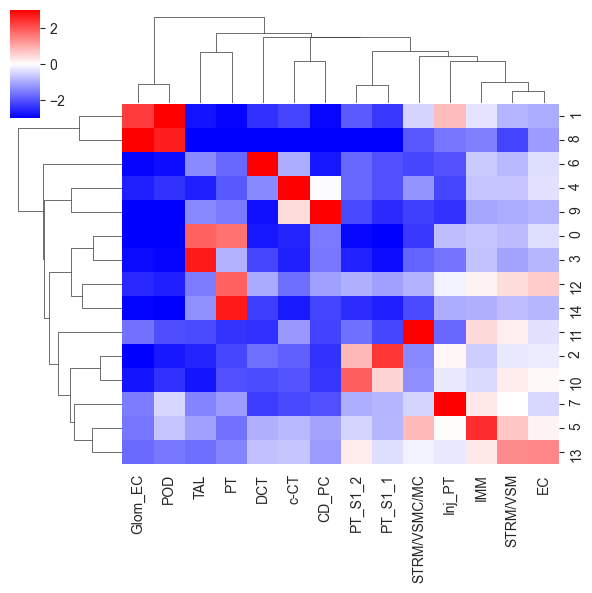

In [78]:
# Select the centroids for a specific value of 'k' for plotting
k_to_plot = k
niche_clusters = (k_centroids[k_to_plot])

# Calculate the average cell types across the 'values' array
tissue_avgs = values.mean(axis=0)

# Compute fold change (fc) of cell types abundance within a neighborhood versus that in the tissue
# This involves a log2 transformation of the ratio of (niche_clusters + tissue_avgs) to tissue_avgs
# The ratio is normalized by the sum across each row (axis=1), ensuring that the sum of ratios for each row is 1
fc = np.log2(((niche_clusters + tissue_avgs) / (niche_clusters + tissue_avgs).sum(axis=1, keepdims=True)) / tissue_avgs)

# Convert the fold change array into a pandas DataFrame for each cell type
fc = pd.DataFrame(fc, columns=sum_cols)

# Create a clustered heatmap using seaborn's clustermap function
# 'fc' DataFrame is used as input
# vmin and vmax set the color scale limits for the heatmap (-3 to 3 in this case)
# cmap='bwr' sets the color palette to blue-white-red
# figsize=(10,10) sets the size of the heatmap
s = sns.clustermap(fc, vmin=-3, vmax=3, cmap='bwr', figsize=(6,6), )#row_color=row_color

This heatmap shows what cell types are enriched or depleted compared to random placement in the tissue and can help guide understanding of what each neighborhood represents.

We can also look at the raw counts of the cell types with in each neighborhoods

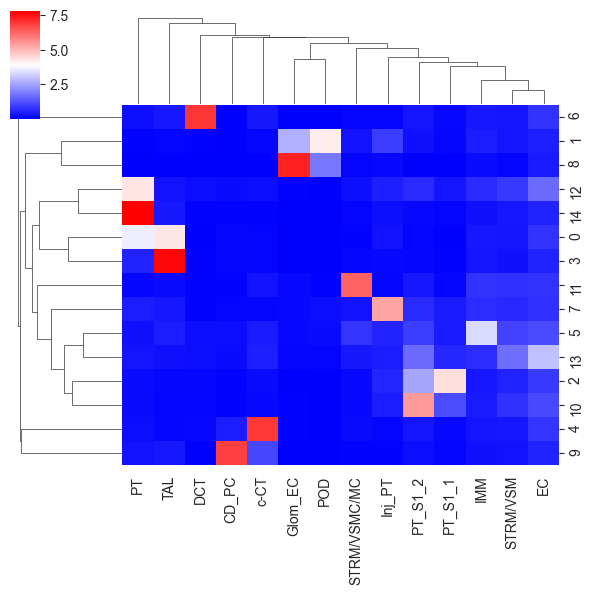

In [79]:
# Convert to DataFrame using RAW values
raw = pd.DataFrame(niche_clusters, columns=sum_cols)

# -----------------------------------------
# Clustermap of RAW values, non-annotated
# -----------------------------------------
s = sns.clustermap(
    raw,
    cmap='bwr',
    figsize=(6, 6),
    row_cluster=True,
    col_cluster=True,
    vmin=None,
    vmax=None
)

plt.show()

## Visualizing the Neighborhoods

Next we can visualize the actual neighborhoods by plotting them in the x, y coordinates. We can use a custom function catplot2 to help with this.

24-0165


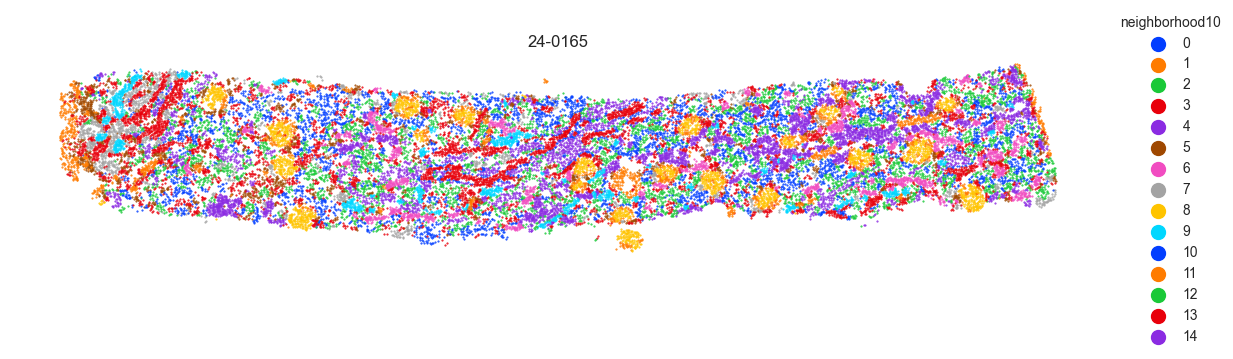

24-0168


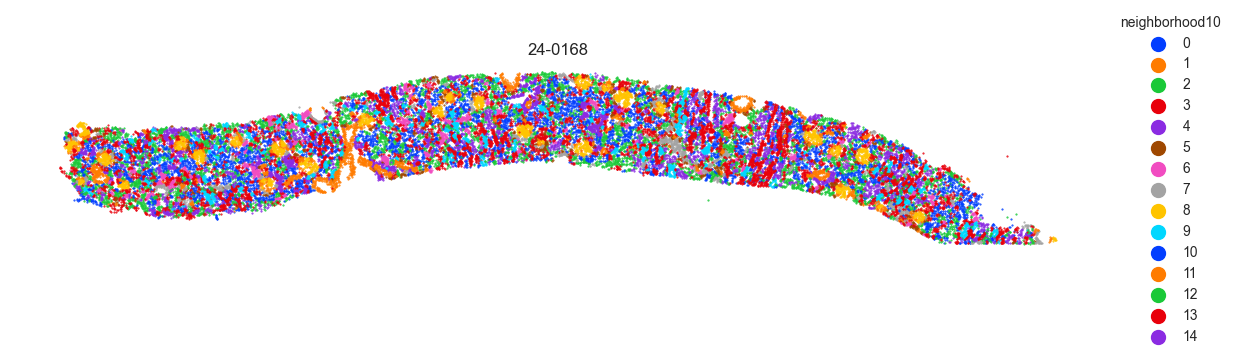

In [80]:
# Plot the neighborhoods on the tissue section, color coded by neighborhood cluster assignment
plt.rcParams["legend.markerscale"] = 20
figs = catplot2(cells,X = 'Y',Y='X',exp = 'Biopsy', legend = True, 
               hue = 'neighborhood10',invert_y=True,size = 1,figsize= (12,10), axis="off", scatter_kws={},)


Sometimes (especially when we have more than 10 neighborhood clusters) it is helpful to look at multiple neighborhoods at the same time, especially if we are considering merging them together.

Let's look at a set of neighborhoods alone to get better visual locations and synergy/interaction with other neighborhoods. Green (12) tends to interact with blue (0) but not so much with orange (3)

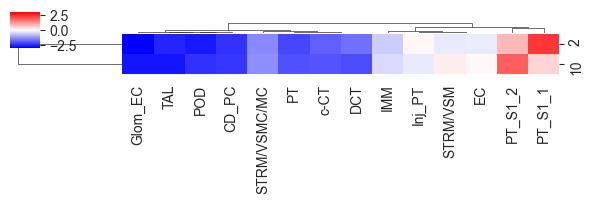

In [81]:
#Subset of clusters to investigate/plot
neigh_list = [2, 10]

#Same code as above, but just with plotting a subset of the clusters
s=sns.clustermap(fc.iloc[neigh_list,:], vmin =-3,vmax = 3,cmap = 'bwr',figsize=(6,2))

24-0165


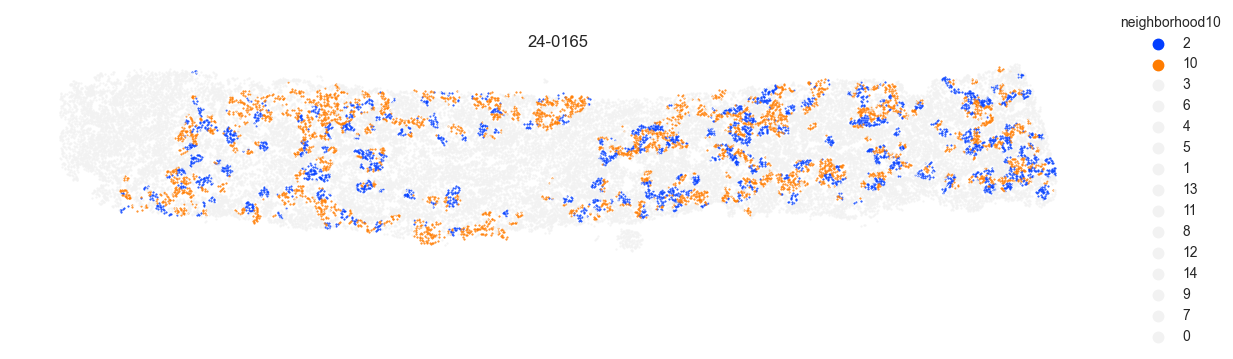

24-0168


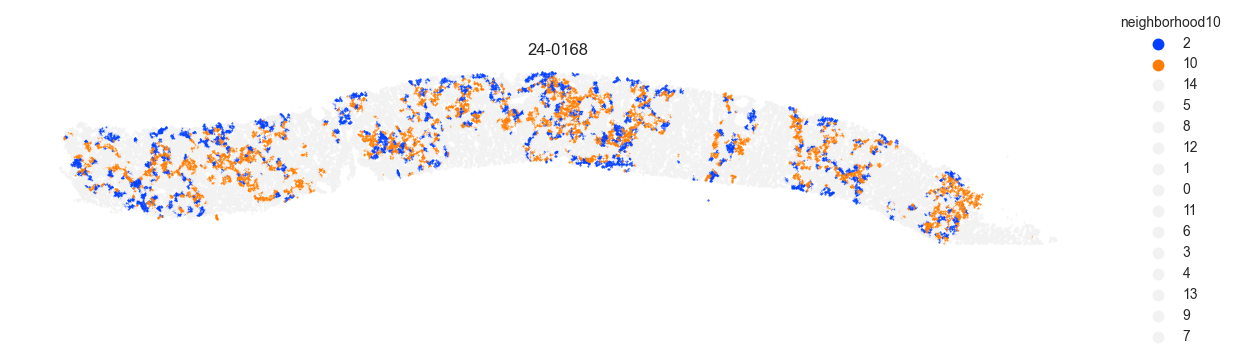

In [82]:
plt.rcParams["legend.markerscale"] = 15
highlight_list = [2, 10]

figs = catplot2_specified(
                cells,X = 'Y',Y='X',
                include = highlight_list,
                exp = 'Biopsy', hue = 'neighborhood10',
                legend = True, invert_y=True,size = 1,
                figsize= (12,10), axis="off", scatter_kws={},
               )

## Naming the neighborhoods

Let's now name the cell neighborhoods with something useful/easy to remember. While this is controversial, I find it helpful to remember and orient the reader in the analysis instead of making them do all the analysis over again.

In [83]:
n_conversion = {
    0: 'TAL & PT enriched',
    1: 'Glomerulus near inj_PT',
    2: 'PT_S1_1 enriched',
    3: 'TAL enriched',
    4: 'c-CT enriched',
    5: 'IMM enriched',
    6: 'DCT enriched',
    7: 'Inj_PT enriched',
    8: 'Glomerulus',
    9: 'CD_PC enriched',

    10: 'PT_S1_2 enriched',
    11: 'VSMC enriched',
    12: 'PT enriched near STRM/EC',
    13: 'STRM/EC enriched',
    14: 'PT enriched',
}
cells['Neighborhood_level1']=cells["neighborhood10"].map(n_conversion)
cells['Neighborhood_level1'].unique()

<ArrowStringArray>
[            'TAL enriched',             'DCT enriched',
         'PT_S1_2 enriched',            'c-CT enriched',
             'IMM enriched',   'Glomerulus near inj_PT',
         'STRM/EC enriched',         'PT_S1_1 enriched',
            'VSMC enriched',               'Glomerulus',
 'PT enriched near STRM/EC',              'PT enriched',
           'CD_PC enriched',          'Inj_PT enriched',
        'TAL & PT enriched']
Length: 15, dtype: str

In [84]:
cells.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['X', 'Y', 'Biopsy', 'Object', 'cluster', 'cluster_2',
       'cell_type_level_1', 'cell_type_level_2', 'CD_PC', 'DCT', 'EC',
       'Glom_EC', 'IMM', 'Inj_PT', 'POD', 'PT', 'PT_S1_1', 'PT_S1_2',
       'STRM/VSM', 'STRM/VSMC/MC', 'TAL', 'c-CT', 'neighborhood10',
       'Neighborhood_level1'],
      dtype='str')>

## Plotting

Now let's create a unique color palette (especially useful when we have MANY neighborhoods or cell types to plot).

In [85]:
#Create unique color palettes for cell type and neighborhood maps
color_list = [
    'gray', 'blue', 'red', 'yellow', 'magenta', 'orange', 'green', 'brown', 'black',
    'skyblue', 'gold', 'plum', 'yellowgreen', 'tan', 'navy', 'bisque',
    'goldenrod', 'blueviolet', 'darkorange', 'teal', 'olive', #'dimgray',
    'indigo', 'lightcoral', 'cyan', 'ivory', 'beige', 'darkblue', 'lightcyan',
    'royalblue'
]

neigh_list = list(cells['Neighborhood_level1'].unique())
dict_neigh = dict(zip(neigh_list, color_list))
dict_neigh


{'TAL enriched': 'gray',
 'DCT enriched': 'blue',
 'PT_S1_2 enriched': 'red',
 'c-CT enriched': 'yellow',
 'IMM enriched': 'magenta',
 'Glomerulus near inj_PT': 'orange',
 'STRM/EC enriched': 'green',
 'PT_S1_1 enriched': 'brown',
 'VSMC enriched': 'black',
 'Glomerulus': 'skyblue',
 'PT enriched near STRM/EC': 'gold',
 'PT enriched': 'plum',
 'CD_PC enriched': 'yellowgreen',
 'Inj_PT enriched': 'tan',
 'TAL & PT enriched': 'navy'}

24-0165


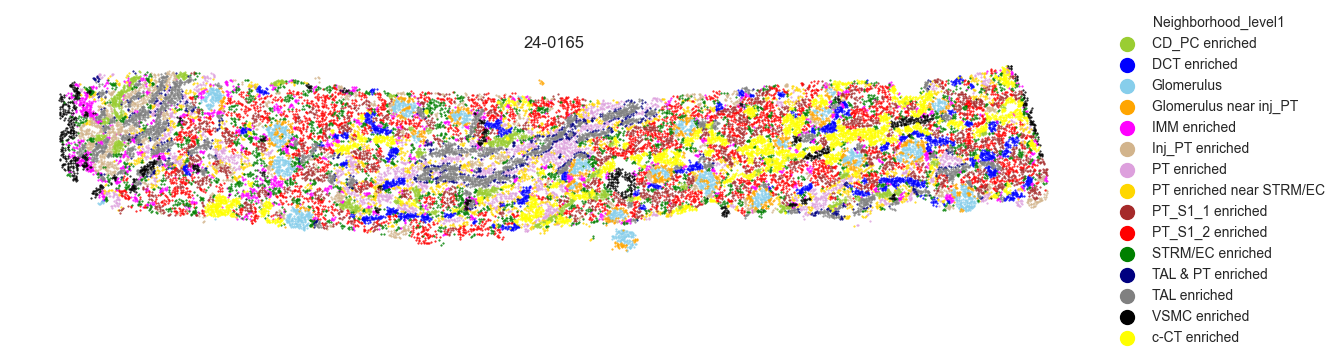

24-0168


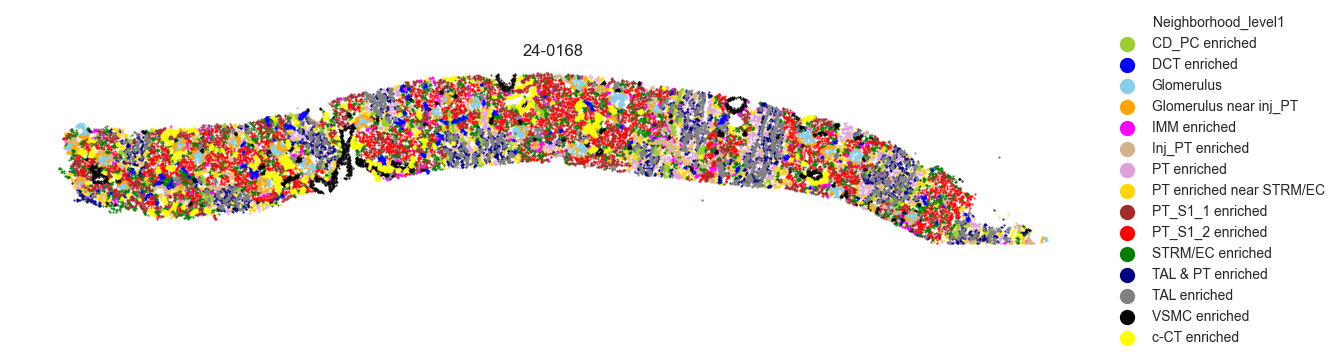

In [86]:
plt.rcParams["legend.markerscale"] = 20
figs = catplot2(cells,X = 'Y',Y='X',exp = 'Biopsy', legend = True, 
                hue = 'Neighborhood_level1',invert_y=True,size = 1,figsize= (12,10), axis="off", scatter_kws={},
                palette = dict_neigh, 
                )

We can plot the heatmap with neighborhood annotations

In [87]:
fc['Neighborhood_level1'] = fc.index.map(n_conversion.get)  # Map indices to Neighborhood names
fc = fc.reset_index(drop=True).set_index('Neighborhood_level1')  # Reset index and set 'Neighborhood_level1' as index

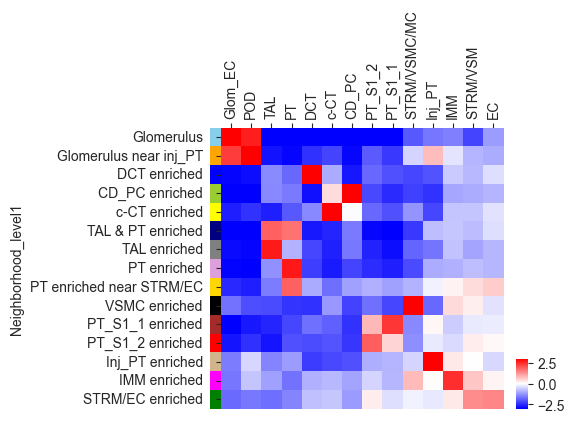

In [88]:
# Merge rows with the same index (Neighborhood) by averaging their values
fc_grouped = fc.groupby(fc.index).mean()

# Create a Series mapping each neighborhood to its color
row_colors = fc_grouped.index.map(dict_neigh)

# Create the clustered heatmap without dendrograms, with row colors
s = sns.clustermap(
    fc_grouped,
    vmin=-3,
    vmax=3,
    cmap='bwr',
    figsize=(6, 5),
    row_colors=row_colors,
    row_cluster=True,  # Remove row dendrogram
    col_cluster=True    # Optional: keep column dendrogram if desired
)

s.ax_row_dendrogram.set_visible(False)
s.ax_col_dendrogram.set_visible(False)

# Move tick labels to the left
s.ax_heatmap.yaxis.tick_left()
s.ax_heatmap.yaxis.set_label_position("left")

# Move x-axis tick labels to the top
s.ax_heatmap.xaxis.set_ticks_position('top')
s.ax_heatmap.xaxis.set_label_position('top')
s.ax_heatmap.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
s.ax_heatmap.set_xticklabels(s.ax_heatmap.get_xticklabels(), rotation=90)

# Offset tick labels more to the left
for tick in s.ax_heatmap.yaxis.get_major_ticks():
    tick.label1.set_horizontalalignment('right')
    tick.label1.set_x(-0.03)  # adjust this value as needed

# Move the colorbar to the right of the heatmap
s.cax.set_position([
    s.ax_heatmap.get_position().x1 + 0.02,  # x-position: right of heatmap
    s.ax_heatmap.get_position().y0,         # y-position: aligned with heatmap
    0.02,                                   # width
    0.1      # height
])

plt.show()

# s.savefig("figures/neighborhood_fc_clustermap.png", dpi=300, bbox_inches='tight')

We can also look at the percentages of neighborhoods

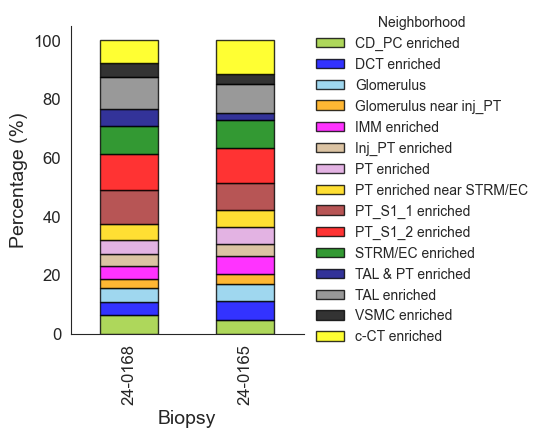

In [89]:
piv, h_order = stacked_bar_plot(
    data = cells, 
    per_cat = 'Neighborhood_level1', 
    grouping = 'Biopsy', 
    fig_sizing=(3,4), 
    name_cat ='Neighborhood', 
    pal_color=dict_neigh,
)

## Save the neighborhood cluster and label

In [90]:
cells.columns

Index(['X', 'Y', 'Biopsy', 'Object', 'cluster', 'cluster_2',
       'cell_type_level_1', 'cell_type_level_2', 'CD_PC', 'DCT', 'EC',
       'Glom_EC', 'IMM', 'Inj_PT', 'POD', 'PT', 'PT_S1_1', 'PT_S1_2',
       'STRM/VSM', 'STRM/VSMC/MC', 'TAL', 'c-CT', 'neighborhood10',
       'Neighborhood_level1'],
      dtype='str')

We want to drop the columns that are between the cell type annotations and the neighborhood annotations, which are not needed for downstream analysis. We will drop the columns in between the cell_type_level_2 column and the neighborhood10 column.

In [91]:
start = cells.columns.get_loc("cell_type_level_2")
end = cells.columns.get_loc("neighborhood10")

# drop columns in between (not including the two endpoints)
cells = cells.drop(cells.columns[start+1:end], axis=1)
cells.columns

Index(['X', 'Y', 'Biopsy', 'Object', 'cluster', 'cluster_2',
       'cell_type_level_1', 'cell_type_level_2', 'neighborhood10',
       'Neighborhood_level1'],
      dtype='str')

In [92]:
cells.to_csv("20260517_kidney_neighborhoods.csv", index=False)

# Explore neighborhoods

We can look at TAL & PT enriched neighborhood, PT enriched neighborhood, and TAL enriched neighborhood to see their spatial location.

24-0165


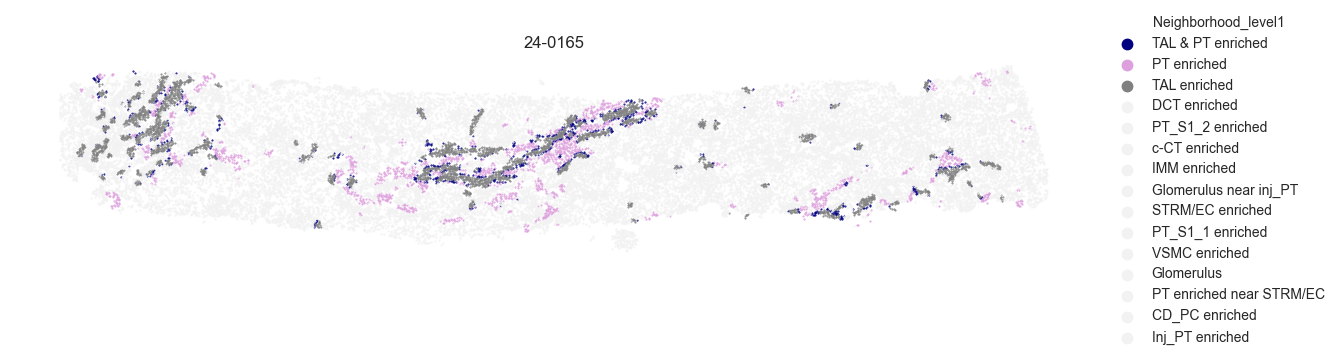

24-0168


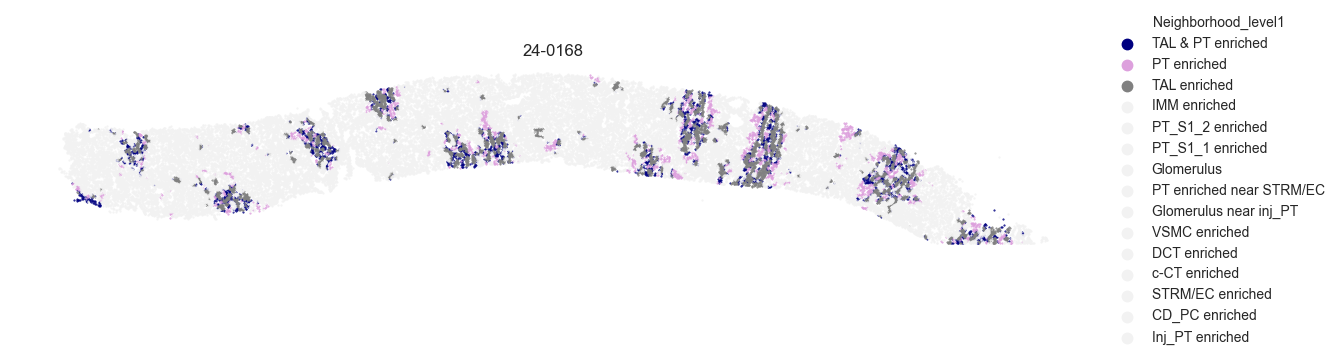

In [93]:
plt.rcParams["legend.markerscale"] = 15
highlight_list = ['TAL & PT enriched', 'PT enriched', 'TAL enriched']

figs = catplot2_specified(
                cells,X = 'Y',Y='X',
                include = highlight_list,
                exp = 'Biopsy', hue = 'Neighborhood_level1',
                palette = dict_neigh,
                legend = True, invert_y=True,size = 1,
                figsize= (12,10), axis="off", scatter_kws={},
               )